# Inverse Problems


# Importing Libraries


In [264]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
import pywt

# Main


## Image loading


In [265]:
DATA_FOLDER_PATH = "../Data" #Specify Data folder directory here
FILENAME = "barbara.jpg" #Specify file name here


filepath = os.path.join(DATA_FOLDER_PATH, FILENAME)

In [266]:
image = Image.open(filepath).convert('L') #Load image as a grayscale
image = np.array(image).astype(np.float32) #Convert Image to array

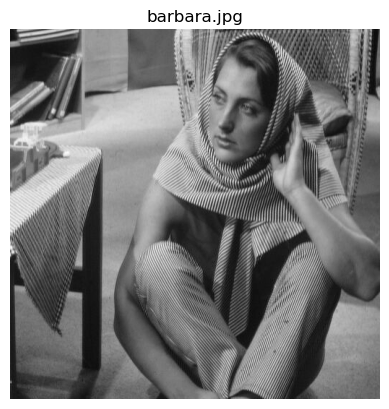

In [267]:
##Display loaded image

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(FILENAME)
plt.show()

## Generating Inpainting Problems


In [268]:
# Generating mask

p = 0.8

A = np.random.binomial(1, p, image.shape).astype(np.uint8)

In [269]:
# Generating noisy image

snr_db = 10

signalPower = np.mean(image**2)
noisePower = signalPower / (10 ** (snr_db / 10))

noise = np.random.normal(0, np.sqrt(noisePower), image.shape)

In [270]:
inpaintingImage = A * image + noise

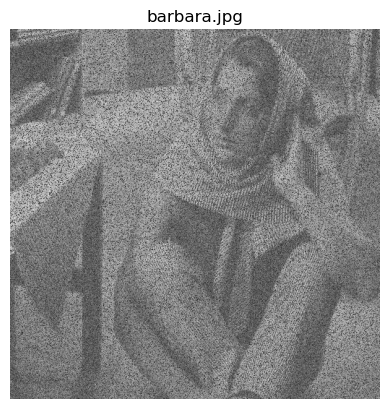

In [271]:
##Display loaded image

plt.imshow(inpaintingImage, cmap='gray')
plt.axis('off')
plt.title(FILENAME)
plt.show()

## Wavelet domain + denoising


In [272]:
wavelet = 'db4'
level = 2

In [273]:
coeffs = pywt.wavedec2(inpaintingImage, wavelet=wavelet, level=level)

In [274]:
# Thresholding coefficients
sigma = np.median(np.abs(coeffs[-1][-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(image.size)) # Universal threshold, by estimating noise from last-level coefficient in the wavelet domain

#threshold = 50 #Uncomment this line for manually specifying threshold

In [275]:
# Soft thresholding, using same parameters as hard threhsolding

new_coeffs_soft = [coeffs[0]]
for details in coeffs[1:]:
    new_details = tuple(np.sign(d) * np.maximum(np.abs(d) - threshold, 0) for d in details)
    new_coeffs_soft.append(new_details)

In [276]:
#Denoising
denoised_image = np.clip(pywt.waverec2(new_coeffs_soft, wavelet=wavelet), 0, 255).astype(np.uint8)

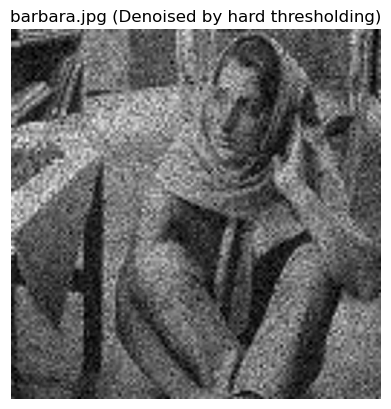

In [277]:
##Display denoised image

plt.imshow(denoised_image, cmap='gray')
plt.axis('off')
plt.title(FILENAME + f" (Denoised by hard thresholding)")
plt.show()

## Discussion


On utilise ici la représentation sparse de signaux 2D (Image), donc l'espace des wavelets. Comme vu en LAB 5, le choix des wavelets et des différents niveaux ddépend de l'image originelle que l'on souhaite estimer. Dans notre cas d'images assez simple (petite taille + grayscale), on préferera choisir une représentation simple (dans notre exemple des wavelet de type db1), avec peu de niveaux de détails. Autrement, on risque d'identifier des niveaux de détails trop fins, et de mal réussir à séparer le bruit de l'image originelle.

En augmentant le nombre de niveaux de la décomposition wavelet, on constate que l'image débruitée perd rapidement du détail. Changer le style des wavelets (db2, sym1, sym2 ... ) semble en revanche avoir ici moins d'effet sur la reconstruction que le débruitage original (Lab 5).

Le paramètre p déterminant le masque à appliquer avant le processus d'inpainting est aussi déterminant pour la résolution de ce problème. En effet, un niveau p trop grand produit une image très incomplète, et cette perte d'informations présentent d'énormes difficultés aux algorithmes de débruitage vus ici. En revanche, pour un paramètre p faible, on retrouve des résultats similaires à ceux vus en Lab 5.
